In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
%alias_magic t timeit
%load_ext memory_profiler

Created `%t` as an alias for `%timeit`.
Created `%%t` as an alias for `%%timeit`.


In [2]:
# import os
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0."

import jax
jax.config.update('jax_platform_name', 'cpu')
jax.devices()

[CpuDevice(id=0)]

In [3]:
import sys
import os
import pickle
import demesdraw, demes
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import namedtuple
from momi3.MOMI import Momi
import pandas as pd

/mnt/turbo/eneswork/jthlab/momi3/src/momi3/utils.py:22: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [39]:
dissertation_dir = '../Enes-s-Dissertation/'

In [5]:
GPU_name = 'Tesla V100-PCIE-16GB'

In [6]:
import sparse

In [7]:
sys.path.append("slurm_performance_tests/")
from timeit_methods import Return
from time_8_pop_admixture import Return8

In [8]:
test_out_folder = 'slurm_performance_tests/timing_tests_out/'

In [9]:
sys.path.append("slurm_performance_tests/")
from timeit_methods import Return
from time_8_pop_admixture import Return8
from Timing_util import *

In [24]:
# Read test results
time_tests = os.listdir(test_out_folder)
rets = []
rets8 = []
for time_test in time_tests:
    ret_path = os.path.join(test_out_folder, time_test)
    with open(ret_path, 'rb') as f:
        ret = pickle.load(f)
        if ret.model_name == 'momi2OOA':
            rets8.append(ret._asdict())
        else:
            rets.append(ret._asdict())
df = pd.DataFrame(rets)
df = df.fillna('None')

In [25]:
df['avg_loglik_time'] = df['loglik_time'].apply(nanmedian)
df['avg_loglik_with_gradient_time'] = df['loglik_with_gradient_time'].apply(nanmedian)

In [26]:
df['demo_name'] = df.apply(
    lambda x: pretty_demo_names(
        x.model_name, x.n_sampled_demes, x.grad_params
    ),
    axis = 1
)

In [27]:
df = df.sort_values(['model_name', 'n_sampled_demes', 'n', 'sequence_length']).reset_index(drop=True)

In [34]:
df = df[
    (df['method'] != 'dadi') | 
    ((df['GPU'] == GTX) &
     (df['n_sampled_demes'] < 4))
].reset_index(drop=True)

In [38]:
# I use runs on 15 CPUs or on GPU
d15 = df[(df['CPU_count'] == 15) | (df['GPU'] != 'None')]
d1 = df[(df['CPU_count'] == 1) | (df['GPU'] != 'None')]


# Tables

## Runtime Table

In [40]:
demo_names = [
    '2D w/ 4 Parameters',
    '3D w/ 5 Parameters',
    '4D w/ 6 Parameters',
    '5D w/ 7 Parameters',
    'OOA 2D, Migrations w/ 10 Parameters',
    'OOA 3D, Migrations w/ 13 Parameters',
    'OOA 4D, Migrations w/ 17 Parameters',
    'OOA 5D, Migrations w/ 21 Parameters',
    'OOA 5D, Pulses w/ 18 Parameters',
]

In [41]:
dns = df.groupby(['demo_name', 'method'])['n'].max()
dns = dns.reset_index().groupby('demo_name')['n'].min().to_dict()
seqlen = 1e8

In [42]:
split_line = '\\\\\n'

In [49]:
for CPU_count in (1, 15):
    
    if CPU_count == 1:
        x = 'A single CPU has been'
    else:
        x = f'{CPU_count} CPUs have been'
    
    caption = f'Computation time of the likelihood ($\ell$) and the gradient ($\\nabla\ell$) for several demographic models.  {x} used in each CPU test and a single GPU for each GPU test. Runtime $\\nabla\ell$ is the total computation time of derivative of all variables and the likelihood.'
    tlabel = f'tbl:ch3:main_runtimes{CPU_count}'
    
    latex_tables = []
    for demo_name in demo_names:
        n = dns[demo_name]
        latex_tables.append(get_table(df, demo_name, n, seqlen, cpu_count=CPU_count))
        if demo_name == 'OOA 5D, Pulses w/ 18 Parameters':
            latex_tables.append(get_table(df, demo_name, 25, seqlen, cpu_count=CPU_count))

    ltable = latex_tables[0]
    ltable = ltable.split(split_line)[2:-1]
    ltable = split_line.join(ltable)
    main_table = '\\begin{tabular}{lll|rrr}\n\\bfseries Demographic model & \\bfseries n & \\bfseries Method & \\bfseries Runtime $\ell$ &\\bfseries Runtime $\\nabla\ell$ & \\bfseries TV' + split_line
    main_table +=  '\hline\hline\n'
    main_table += ltable

    for ltable in latex_tables[1:-1]:
        ltable = ltable.split(split_line)[2:-1]
        ltable = split_line.join(ltable)
        main_table += '\\\ \n \hline\n' + ltable

    ltable = latex_tables[-1]
    ltable = ltable.split(split_line)[2:]
    ltable[-1] = '\hline\n' + ltable[-1]
    ltable = split_line.join(ltable)
    main_table += '\\\ \n\hline\n' + ltable

    #main_table = add_captions(main_table, caption, tlabel)
    main_table = main_table.replace('dadi', r'$\partial a \partial i$')

    text_file = open(f"{dissertation_dir}tables/Runtimes{CPU_count}.tex", "w")
    n = text_file.write(main_table)
    text_file.close()

In [50]:
print(main_table)

\begin{tabular}{lll|rrr}
\bfseries Demographic model & \bfseries n & \bfseries Method & \bfseries Runtime $\ell$ &\bfseries Runtime $\nabla\ell$ & \bfseries TV\\
\hline\hline
\multirow[c]{4}{*}{2D w/ 4 Parameters} & \multirow[c]{4}{*}{200} & moments & 0.94 & 5.61 & 3.7e-06 \\
 &  & momi2 & 0.71 & 1.94 & -- \\
 &  & momi3 (CPU) & 0.41 & 0.65 & 2.3e-07 \\
 &  & momi3 (GPU) & \bfseries 0.06 & \bfseries 0.08 & \bfseries 2.1e-07 \\ 
 \hline
\multirow[c]{4}{*}{3D w/ 5 Parameters} & \multirow[c]{4}{*}{200} & moments & 77.75 & 544.68 & 5.4e-06 \\
 &  & momi2 & 3.99 & 12.33 & -- \\
 &  & momi3 (CPU) & 2.10 & 3.81 & 2e-07 \\
 &  & momi3 (GPU) & \bfseries 0.40 & \bfseries 0.50 & \bfseries 1.8e-07 \\ 
 \hline
\multirow[c]{4}{*}{4D w/ 6 Parameters} & \multirow[c]{4}{*}{5} & moments & 0.23 & 1.81 & 8.2e-06 \\
 &  & momi2 & 0.04 & 0.14 & -- \\
 &  & momi3 (CPU) & \bfseries 0.01 & \bfseries 0.01 & 8.3e-08 \\
 &  & momi3 (GPU) & 0.01 & 0.01 & \bfseries 7.6e-08 \\ 
 \hline
\multirow[c]{4}{*}{5D w/ 7 Par

## Compilation Times

In [28]:
caption = 'Compilation time of momi3'
tlabel = 'tbl:ch3:compilation'

In [29]:
mom3s = d15[
    (d15['method'] == 'momi3') &
    (d15['sequence_length'] == 1e8)
].reset_index(drop=True)

comp_time = mom3s[['demo_name', 'n', 'GPU', 'loglik_compilation_time','loglik_with_gradient_compilation_time']]
comp_time = comp_time.rename(columns={
    'demo_name': 'Demographic model',
    'GPU':'Proccessor',
    'loglik_compilation_time': '$\ell$',
    'loglik_with_gradient_compilation_time': '$\\nabla\ell$'
})

comp_time = comp_time.set_index(['Demographic model', 'n'])
comp_time = comp_time.pivot(columns='Proccessor', values=['$\ell$', '$\\nabla\ell$'])

In [30]:
ret = []
for demo_name in demo_names:
    x = comp_time[[i[0] == demo_name for i in list(comp_time.index)]]
    x = x.style.format('{:.2f}').to_latex(multicol_align='c')
    x = x.split(split_line)
    x = x[3:-1]
    x = split_line.join(x)
    x = '\\hline\n' + x
    ret.append(x)
x = split_line.join(ret + ['\hline\n\\end{tabular}\n'])

head = '\\begin{tabular}{ll|rrrr}\n\\bfseries Demographic model & \\bfseries n & \\bfseries $\\ell$-CPU & \\bfseries $\\ell$-GPU & \\bfseries $\\nabla\\ell$-CPU & \\bfseries $\\nabla\\ell$-GPU \\\ \n'
head += '\hline'
x = head + x
x = x.replace('nan', '--')

In [31]:
#x = add_captions(x, caption, tlabel)

In [32]:
text_file = open(f"{dissertation_dir}tables/CompilationTime.tex", "w")
n = text_file.write(x)
text_file.close()

In [33]:
print(x)

\begin{tabular}{ll|rrrr}
\bfseries Demographic model & \bfseries n & \bfseries $\ell$-CPU & \bfseries $\ell$-GPU & \bfseries $\nabla\ell$-CPU & \bfseries $\nabla\ell$-GPU \\ 
\hline\hline
\multirow[c]{6}{*}{2D w/ 4 Parameters} & 5 & 0.32 & 0.56 & 3.24 & 4.51 \\
 & 10 & 0.37 & 0.57 & 3.69 & 4.31 \\
 & 25 & 0.36 & 0.65 & 3.57 & 4.56 \\
 & 50 & 0.44 & 0.70 & 4.06 & 4.84 \\
 & 100 & 0.55 & 0.70 & 4.05 & 4.82 \\
 & 200 & 0.89 & 0.78 & 4.71 & 5.87 \\
\hline
\multirow[c]{6}{*}{3D w/ 5 Parameters} & 5 & 0.44 & 0.76 & 3.79 & 5.16 \\
 & 10 & 0.50 & 0.79 & 3.97 & 5.00 \\
 & 25 & 0.53 & 0.91 & 4.11 & 5.31 \\
 & 50 & 0.78 & 0.92 & 4.73 & 5.80 \\
 & 100 & 1.00 & 0.99 & 5.07 & 6.87 \\
 & 200 & 2.58 & 1.41 & 8.50 & 13.13 \\
\hline
\multirow[c]{4}{*}{4D w/ 6 Parameters} & 5 & 0.59 & 0.96 & 4.26 & 5.63 \\
 & 10 & 0.68 & 1.01 & 4.75 & 5.72 \\
 & 25 & 0.77 & 1.18 & 4.70 & 6.59 \\
 & 50 & 1.20 & 1.16 & 5.78 & 7.05 \\
\hline
\multirow[c]{4}{*}{5D w/ 7 Parameters} & 5 & 0.76 & 1.20 & 4.87 & 6.40 \\
 & 10 & 0

# Plots

In [34]:
SEQLEN = [1e6, 1e7, 1e8]

In [35]:
colors = dict(zip(
    ["moments", "momi2", "momi3 (CPU)", "momi3 (GPU)"],
    ["blue", "orange", "green", "red"]
))

markers = dict(zip(
    ["moments", "momi2", "momi3 (CPU)", "momi3 (GPU)"],
    ["o", "s", "v", "^"]
))

seq_markers = dict(zip(SEQLEN, ['P', 'X', 'D']))

## Constant Growth

In [36]:
from time_no_mig_no_adm import get_demo_2, get_demo_3, get_demo_4, get_demo_5

In [37]:
methods = ["moments", "momi2", "momi3", "momi3"]
GPU = ['None', 'None', 'None', GPU_name]

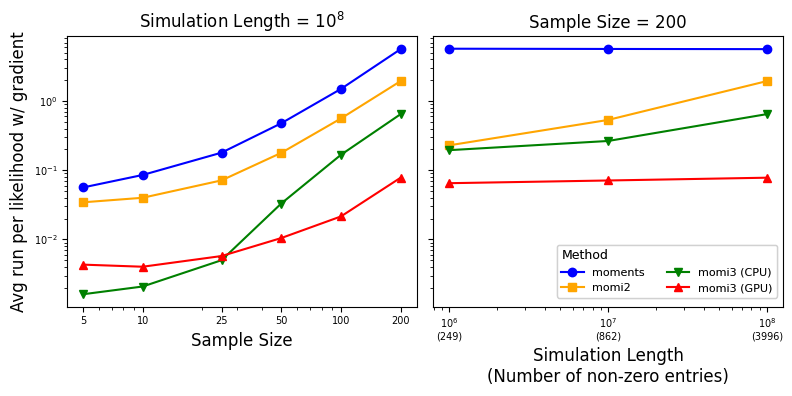

In [38]:
demo_name = '2D w/ 4 Parameters'
figure_name = 'Constans2D'

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(8, 4))

# PLOT 1 n vs runtime
x_name = 'n'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median

# filters
sequence_length = 1e8

for gpu, method in zip(GPU, methods):
    x, y = get_x_y(
        d15,
        x_name=x_name,
        y_name=y_name,
        summary_stat=summary_stat,
        demo_name=demo_name,
        method=method,
        sequence_length=sequence_length,
        GPU=gpu
    )
    
    label = get_label(method, gpu)
    ax1.plot(x, y, '-'+markers[label], label=label, color=colors[label])

ax1.set_ylabel("Avg run per likelihood w/ gradient", fontsize=12);
ax1.set_xlabel("Sample Size", fontsize=12)
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xticks(x, x)
ax1.set_title(r'Simulation Length = $10^8$', fontsize=12);
ax1.set_ylabel("Avg run per likelihood w/ gradient")    


# PLOT 2 seqlen vs runtime
x_name = 'sequence_length'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median

# filters
n = 200

for gpu, method in zip(GPU, methods):
    x, y = get_x_y(
        d15,
        x_name=x_name,
        y_name=y_name,
        summary_stat=summary_stat,
        demo_name=demo_name,
        method=method,
        n=n,
        GPU=gpu
    )
    
    label = get_label(method, gpu)
    ax2.plot(x, y, '-'+markers[label], label=label, color=colors[label])

jsfs_density, _ = get_x_y(
    d15,
    x_name='jsfs_density',
    y_name=y_name,
    summary_stat=summary_stat,
    demo_name=demo_name,
    method=method,
    n=n,
    GPU=gpu
)
non_zeros = [int(i * (n + 1) ** 2) for i in jsfs_density]

ax2.set_xlabel("Simulation Length\n(Number of non-zero entries)", fontsize=12)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xticks(SEQLEN, [f"${i}$\n({j})" for i, j in zip(['10^6', '10^7', '10^8'], non_zeros)])
ax2.set_title(f'Sample Size = {n}', fontsize=12);

l1 = plt.legend(title='Method', ncol=2, bbox_to_anchor=(1., 0.25), title_fontproperties={'size':9})
l1._legend_box.align = "left"
ax2.add_artist(l1)
plt.tight_layout()
plt.savefig(f"{dissertation_dir}figures/chapter3/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

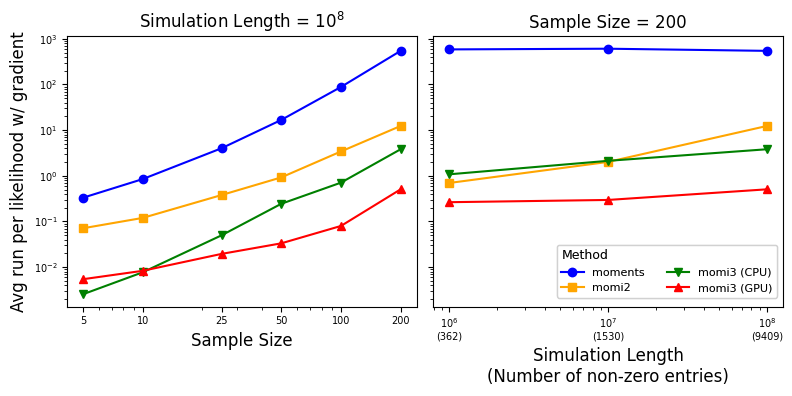

In [39]:
demo_name = '3D w/ 5 Parameters'
figure_name = 'Constans3D'

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(8, 4))

# PLOT 1 n vs runtime
x_name = 'n'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median

# filters
sequence_length = 1e8

for gpu, method in zip(GPU, methods):
    x, y = get_x_y(
        d15,
        x_name=x_name,
        y_name=y_name,
        summary_stat=summary_stat,
        demo_name=demo_name,
        method=method,
        sequence_length=sequence_length,
        GPU=gpu
    )
    
    label = get_label(method, gpu)
    ax1.plot(x, y, '-'+markers[label], label=label, color=colors[label])
         
ax1.set_ylabel("Avg run per likelihood w/ gradient", fontsize=12);
ax1.set_xlabel("Sample Size", fontsize=12)
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xticks(x, x)
ax1.set_title(r'Simulation Length = $10^8$', fontsize=12);
ax1.set_ylabel("Avg run per likelihood w/ gradient")    


# PLOT 2 seqlen vs runtime
x_name = 'sequence_length'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median

# filters
n = 200

for gpu, method in zip(GPU, methods):
    x, y = get_x_y(
        d15,
        x_name=x_name,
        y_name=y_name,
        summary_stat=summary_stat,
        demo_name=demo_name,
        method=method,
        n=n,
        GPU=gpu
    )
    
    label = get_label(method, gpu)
    ax2.plot(x, y, '-'+markers[label], label=label, color=colors[label])

jsfs_density, _ = get_x_y(
    d15,
    x_name='jsfs_density',
    y_name=y_name,
    summary_stat=summary_stat,
    demo_name=demo_name,
    method=method,
    n=n,
    GPU=gpu
)
non_zeros = [int(i * (n + 1) ** 3) for i in jsfs_density]

ax2.set_xlabel("Simulation Length\n(Number of non-zero entries)", fontsize=12)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xticks(SEQLEN, [f"${i}$\n({j})" for i, j in zip(['10^6', '10^7', '10^8'], non_zeros)])
ax2.set_title(f'Sample Size = {n}', fontsize=12);

l1 = plt.legend(title='Method', ncol=2, bbox_to_anchor=(1., 0.25), title_fontproperties={'size':9})
l1._legend_box.align = "left"
ax2.add_artist(l1)
plt.tight_layout()
plt.savefig(f"{dissertation_dir}figures/chapter3/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

In [40]:
methods = ["momi2", "momi3", "momi3"]
GPU = ['None', 'None', GPU_name]

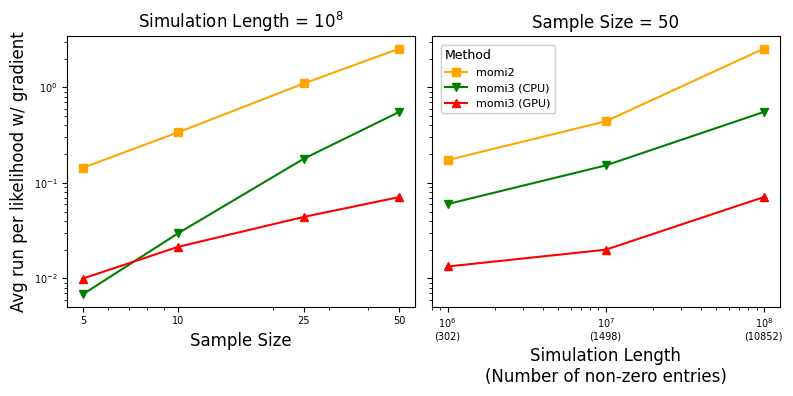

In [41]:
demo_name = '4D w/ 6 Parameters'
figure_name = 'Constans4D'

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(8, 4))

# PLOT 1 n vs runtime
x_name = 'n'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median

# filters
sequence_length = 1e8

for gpu, method in zip(GPU, methods):
    x, y = get_x_y(
        d15,
        x_name=x_name,
        y_name=y_name,
        summary_stat=summary_stat,
        demo_name=demo_name,
        method=method,
        sequence_length=sequence_length,
        GPU=gpu
    )
    
    label = get_label(method, gpu)
    ax1.plot(x, y, '-'+markers[label], label=label, color=colors[label])

ax1.set_ylabel("Avg run per likelihood w/ gradient", fontsize=12);
ax1.set_xlabel("Sample Size", fontsize=12)
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xticks(x, x)
ax1.set_title(r'Simulation Length = $10^8$', fontsize=12);
ax1.set_ylabel("Avg run per likelihood w/ gradient")    


# PLOT 2 seqlen vs runtime
x_name = 'sequence_length'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median

# filters
n = 50

for gpu, method in zip(GPU, methods):
    x, y = get_x_y(
        d15,
        x_name=x_name,
        y_name=y_name,
        summary_stat=summary_stat,
        demo_name=demo_name,
        method=method,
        n=n,
        GPU=gpu
    )
    
    label = get_label(method, gpu)
    ax2.plot(x, y, '-'+markers[label], label=label, color=colors[label])

jsfs_density, _ = get_x_y(
    d15,
    x_name='jsfs_density',
    y_name=y_name,
    summary_stat=summary_stat,
    demo_name=demo_name,
    method=method,
    n=n,
    GPU=gpu
)
non_zeros = [int(i * (n + 1) ** 4) for i in jsfs_density]

ax2.set_xlabel("Simulation Length\n(Number of non-zero entries)", fontsize=12)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xticks(SEQLEN, [f"${i}$\n({j})" for i, j in zip(['10^6', '10^7', '10^8'], non_zeros)])
ax2.set_title(f'Sample Size = {n}', fontsize=12);

l1 = plt.legend(title='Method', loc=1, ncol=1, bbox_to_anchor=(0.37, 0.99), title_fontproperties={'size':9})
l1._legend_box.align = "left"
ax2.add_artist(l1)
plt.tight_layout()
plt.savefig(f"{dissertation_dir}figures/chapter3/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

In [42]:
methods = ["momi2", "momi3", "momi3"]
GPU = ['None', 'None', GPU_name]

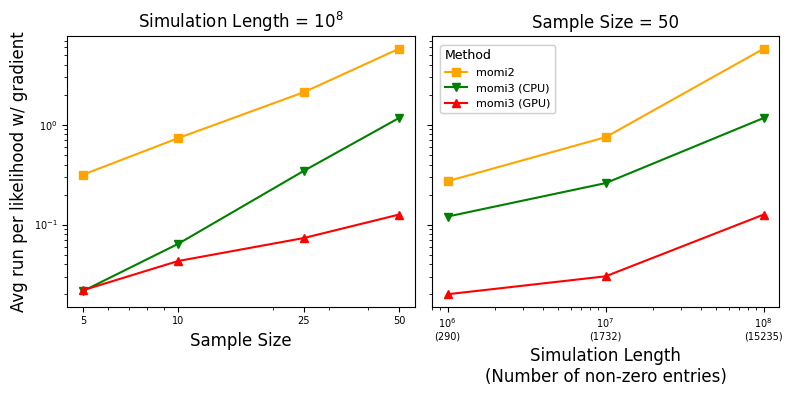

In [43]:
demo_name = '5D w/ 7 Parameters'
figure_name = 'Constans5D'

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(8, 4))

# PLOT 1 n vs runtime
x_name = 'n'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median

# filters
sequence_length = 1e8

for gpu, method in zip(GPU, methods):
    x, y = get_x_y(
        d15,
        x_name=x_name,
        y_name=y_name,
        summary_stat=summary_stat,
        demo_name=demo_name,
        method=method,
        sequence_length=sequence_length,
        GPU=gpu
    )
    
    label = get_label(method, gpu)
    ax1.plot(x, y, '-'+markers[label], label=label, color=colors[label])

ax1.set_ylabel("Avg run per likelihood w/ gradient", fontsize=12);
ax1.set_xlabel("Sample Size", fontsize=12)
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xticks(x, x)
ax1.set_title(r'Simulation Length = $10^8$', fontsize=12);
ax1.set_ylabel("Avg run per likelihood w/ gradient")    


# PLOT 2 seqlen vs runtime
x_name = 'sequence_length'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median

# filters
n = 50

for gpu, method in zip(GPU, methods):
    x, y = get_x_y(
        d15,
        x_name=x_name,
        y_name=y_name,
        summary_stat=summary_stat,
        demo_name=demo_name,
        method=method,
        n=n,
        GPU=gpu
    )
    
    label = get_label(method, gpu)
    ax2.plot(x, y, '-'+markers[label], label=label, color=colors[label])

jsfs_density, _ = get_x_y(
    d15,
    x_name='jsfs_density',
    y_name=y_name,
    summary_stat=summary_stat,
    demo_name=demo_name,
    method=method,
    n=n,
    GPU=gpu
)
non_zeros = [int(i * (n + 1) ** 5) for i in jsfs_density]

ax2.set_xlabel("Simulation Length\n(Number of non-zero entries)", fontsize=12)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xticks(SEQLEN, [f"${i}$\n({j})" for i, j in zip(['10^6', '10^7', '10^8'], non_zeros)])
ax2.set_title(f'Sample Size = {n}', fontsize=12);

l1 = plt.legend(title='Method', loc=1, ncol=1, bbox_to_anchor=(0.37, 0.99), title_fontproperties={'size':9})
l1._legend_box.align = "left"
ax2.add_artist(l1)
plt.tight_layout()
plt.savefig(f"{dissertation_dir}figures/chapter3/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

# OOA Migration

In [44]:
methods = ["moments", "momi3"]
GPU = ['None', GPU_name]

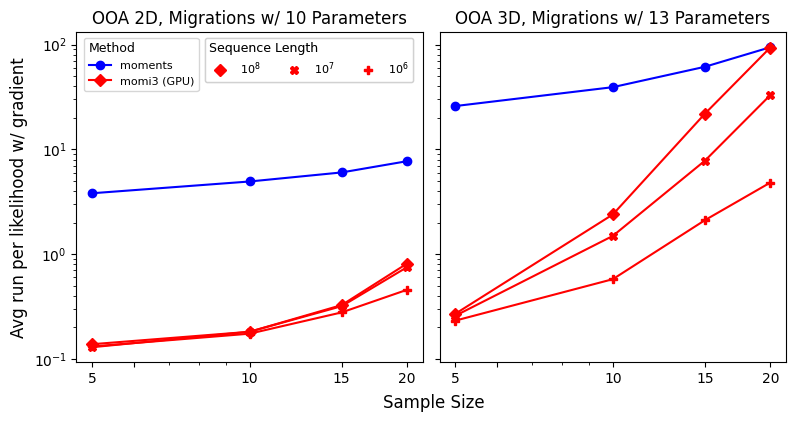

In [45]:
figure_name = 'OOA2D3D'

demo_names = [
   'OOA 2D, Migrations w/ 10 Parameters',
   'OOA 3D, Migrations w/ 13 Parameters',
]

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(8, 4))

# PLOT 1 n vs runtime
x_name = 'n'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median

# filters

for i, demo_name in enumerate(demo_names):
    ax = axs[i]
    label_print = True
    
    for sequence_length in [1e8, 1e7, 1e6]:
        for gpu, method in zip(GPU, methods):
            if (sequence_length == 1e8) | (method == 'momi3'):
                x, y = get_x_y(
                    d15,
                    x_name=x_name,
                    y_name=y_name,
                    summary_stat=summary_stat,
                    demo_name=demo_name,
                    method=method,
                    sequence_length=sequence_length,
                    GPU=gpu
                )

                label = get_label(method, gpu)

                if method == 'momi3':
                    ax.plot(x, y, '-'+seq_markers[sequence_length], label=label, color=colors[label])
                else:
                    ax.plot(x, y, '-'+markers[label], label=label, color=colors[label])


    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xticks([5, 6, 10, 15, 20], [5,'',10, 15, 20])
    ax.set_title(demo_name, fontsize=12);
    ax.tick_params(axis='both', which='major', labelsize=10)
    

axs[0].set_ylabel("Avg run per likelihood w/ gradient", fontsize=12)

for sequence_length in [1e8, 1e7, 1e6]:
    axs[0].plot([], [], seq_markers[sequence_length], color=colors['momi3 (GPU)'], label=sequence_length)

lines = axs[0].get_lines()
l1 = plt.legend(
    [lines[i] for i in [0,1]], ["moments", "momi3 (GPU)"],
    title='Method', bbox_to_anchor=(-0.68, 1.0), title_fontproperties={'size':9}
)
l2 = plt.legend(
    [lines[i] for i in [-3,-2,-1]], [fr'${i}$' for i in [r"10^8", "10^7", "10^6"]],
    title='Sequence Length', bbox_to_anchor=(-0.06, 1.0), ncol=3, title_fontproperties={'size':9}
)
l1._legend_box.align = "left"
l2._legend_box.align = "left"

ax.add_artist(l1)
ax.add_artist(l2)
plt.tight_layout()
axs[0].text(18, 0.034, 'Sample Size', fontsize=12)
plt.savefig(f"{dissertation_dir}figures/chapter3/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

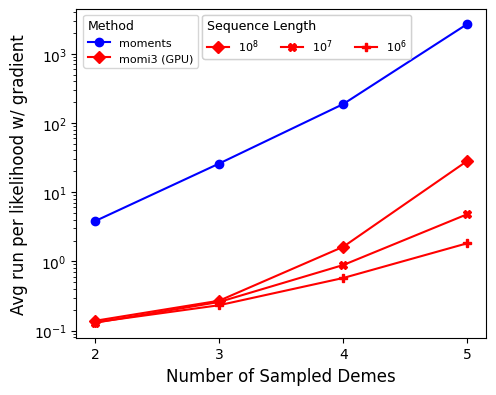

In [46]:
figure_name = 'OOA2D3D4D5D'

x_name = 'n_sampled_demes'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median

# filters
n = 5

fig, ax = plt.subplots(1,1, figsize=(5,4))

label_print = True
for sequence_length in [1e8, 1e7, 1e6]:
    for gpu, method in zip(GPU, methods):
        if (sequence_length == 1e8) | (method == 'momi3'):
            x, y = get_x_y(
                d15,
                x_name=x_name,
                y_name=y_name,
                summary_stat=summary_stat,
                model_name='IWM_constant',
                method=method,
                sequence_length=sequence_length,
                GPU=gpu,
                n=5,
            )

            label = get_label(method, gpu)

            if method == 'momi3':
                ax.plot(x, y, '-'+seq_markers[sequence_length], label=label, color=colors[label])
            else:
                ax.plot(x, y, '-'+markers[label], label=label, color=colors[label])

                
for gpu, method in zip(GPU, methods):
    label = get_label(method, gpu)
    ax.plot([], [], 'o', color=colors[label], label=label)
    
for sequence_length in [1e8, 1e7, 1e6]:
    axs[0].plot([], [], seq_markers[sequence_length], color=colors['momi3 (GPU)'], label=sequence_length)
                
ax.set_yscale('log')

lines = ax.get_lines()
l1 = plt.legend(
    [lines[i] for i in [0,1]], ["moments", "momi3 (GPU)"],
    title='Method', bbox_to_anchor=(0.31, 1.0), title_fontproperties={'size':9}
)
l2 = plt.legend(
    [lines[i] for i in [-5,-4,-3]], [fr'${i}$' for i in [r"10^8", "10^7", "10^6"]],
    title='Sequence Length', bbox_to_anchor=(0.83, 1.0), ncol=3, title_fontproperties={'size':9}
)
l1._legend_box.align = "left"
l2._legend_box.align = "left"
l1._legend_title_box

ax.add_artist(l1)
ax.add_artist(l2)

ax.set_xticks(x, x)
ax.tick_params(axis='both', which='major', labelsize=10)
plt.xlabel('Number of Sampled Demes', fontsize=12)
plt.ylabel("Avg run per likelihood w/ gradient", fontsize=12);
plt.tight_layout()
plt.savefig(f"{dissertation_dir}figures/chapter3/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

In [47]:
methods = ["momi2", "momi3", "momi3"]
GPU = ['None', 'None', GPU_name]

In [48]:
demo_name = 'OOA 5D, Pulses w/ 18 Parameters'

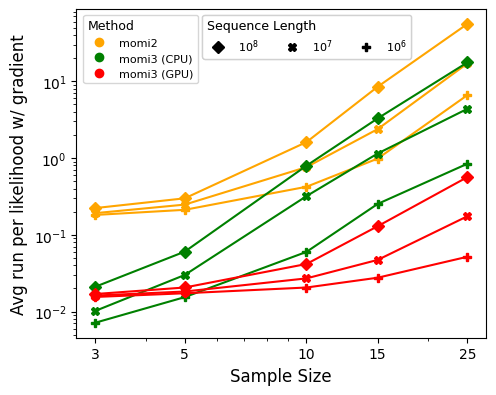

In [49]:
figure_name = 'OOA5DPulse'

x_name = 'n'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median


fig, ax = plt.subplots(1,1, figsize=(5,4))

label_print = True
for gpu, method in zip(GPU, methods):
    for sequence_length in [1e8, 1e7, 1e6]:
        x, y = get_x_y(
            d15,
            x_name=x_name,
            y_name=y_name,
            summary_stat=summary_stat,
            demo_name=demo_name,
            method=method,
            sequence_length=sequence_length,
            GPU=gpu,
        )

        label = get_label(method, gpu)

        ax.plot(x, y, '-'+seq_markers[sequence_length], color=colors[label])

for gpu, method in zip(GPU, methods):
    label = get_label(method, gpu)
    ax.plot([], [], 'o', color=colors[label], label=label)
    
for sequence_length in [1e8, 1e7, 1e6]:
    ax.plot([], [], seq_markers[sequence_length], color='black', label=sequence_length)

ax.set_yscale('log')
ax.set_xscale('log')
lines = ax.get_lines()

l1 = plt.legend(
    [lines[i] for i in [-6,-5,-4]], ["momi2", "momi3 (CPU)", "momi3 (GPU)"],
    title='Method', bbox_to_anchor=(0.31, 1.0), title_fontproperties={'size':9}
)
l2 = plt.legend(
    [lines[i] for i in [-3,-2,-1]], [fr'${i}$' for i in [r"10^8", "10^7", "10^6"]],
    title='Sequence Length', bbox_to_anchor=(0.83, 1.0), ncol=3, title_fontproperties={'size':9}
)

l1._legend_box.align = "left"
l2._legend_box.align = "left"
l1._legend_title_box

ax.add_artist(l1)
ax.add_artist(l2)
ax.set_xticks(x, x)
ax.tick_params(axis='both', which='major', labelsize=10)
#ax.set_title(f'{demo_name}')
plt.xlabel('Sample Size', fontsize=12)
plt.ylabel("Avg run per likelihood w/ gradient", fontsize=12);
plt.tight_layout()
plt.savefig(f"{dissertation_dir}figures/chapter3/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

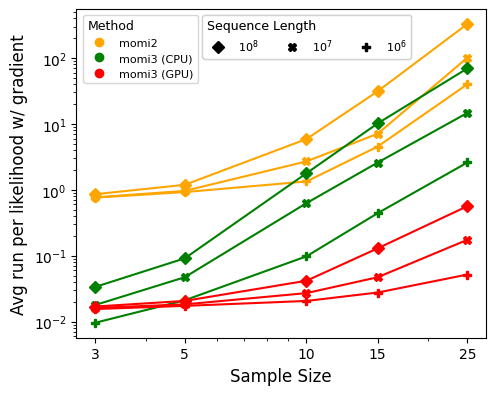

In [50]:
figure_name = 'OOA5DPulse'

x_name = 'n'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median


fig, ax = plt.subplots(1,1, figsize=(5,4))

label_print = True
for gpu, method in zip(GPU, methods):
    for sequence_length in [1e8, 1e7, 1e6]:
        x, y = get_x_y(
            d1,
            x_name=x_name,
            y_name=y_name,
            summary_stat=summary_stat,
            demo_name=demo_name,
            method=method,
            sequence_length=sequence_length,
            GPU=gpu,
        )

        label = get_label(method, gpu)

        ax.plot(x, y, '-'+seq_markers[sequence_length], color=colors[label])

for gpu, method in zip(GPU, methods):
    label = get_label(method, gpu)
    ax.plot([], [], 'o', color=colors[label], label=label)
    
for sequence_length in [1e8, 1e7, 1e6]:
    ax.plot([], [], seq_markers[sequence_length], color='black', label=sequence_length)

ax.set_yscale('log')
ax.set_xscale('log')
lines = ax.get_lines()

l1 = plt.legend(
    [lines[i] for i in [-6,-5,-4]], ["momi2", "momi3 (CPU)", "momi3 (GPU)"],
    title='Method', bbox_to_anchor=(0.31, 1.0), title_fontproperties={'size':9}
)
l2 = plt.legend(
    [lines[i] for i in [-3,-2,-1]], [fr'${i}$' for i in [r"10^8", "10^7", "10^6"]],
    title='Sequence Length', bbox_to_anchor=(0.83, 1.0), ncol=3, title_fontproperties={'size':9}
)

l1._legend_box.align = "left"
l2._legend_box.align = "left"
l1._legend_title_box

ax.add_artist(l1)
ax.add_artist(l2)
ax.set_xticks(x, x)
ax.tick_params(axis='both', which='major', labelsize=10)
#ax.set_title(f'{demo_name}')
plt.xlabel('Sample Size', fontsize=12)
plt.ylabel("Avg run per likelihood w/ gradient", fontsize=12);
plt.tight_layout()
#plt.savefig(f"{dissertation_dir}figures/chapter3/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

# 8 POP

In [51]:
from time_8_pop_admixture import Return8

In [52]:
demo8 = demes.load('timing_tests_yaml/8_pop_3_admix.yaml')

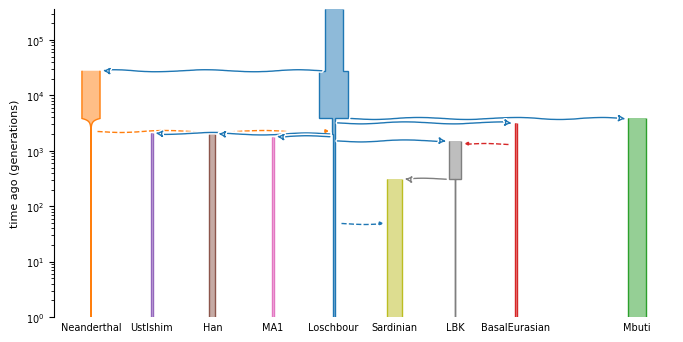

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharey=True)
demesdraw.tubes(demo8, log_time=True, ax=ax)
plt.savefig(f"{dissertation_dir}figures/chapter3/demo/8_pop_adm.pdf", format="pdf", bbox_inches="tight", dpi=600)
# axis_off = ~axis_off
# ax.get_yaxis().set_visible(axis_off)
# demo_name = next(demo_names)
# ax.set_title(demo_name)

In [54]:
rets8 = pd.DataFrame(rets8)
rets8 = rets8.fillna('None')
sequence_length = 1e8

In [55]:
colors["momi3 - bs (CPU)"] = "springgreen"
colors["momi3 - bs (GPU)"] = "firebrick"

In [56]:
markers["momi3 - bs (CPU)"] = "<"
markers["momi3 - bs (GPU)"] = ">"

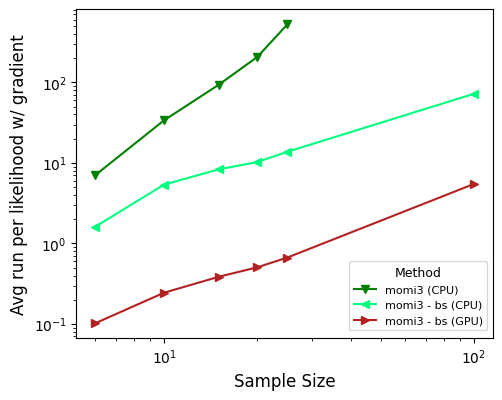

In [57]:
figure_name = 'OOA8DPulse'

method = 'momi3'


x_name = 'n'
y_name = 'loglik_with_gradient_time'
summary_stat = np.median

GPU = ['None', 'None', GPU_name]
bound_samplers = [False, True, True]

fig, ax = plt.subplots(1,1, figsize=(5,4))

for gpu, bound_sampler in zip(GPU, bound_samplers):

    x, y = get_x_y(
        rets8,
        x_name=x_name,
        y_name=y_name,
        summary_stat=summary_stat,
        method=method,
        sequence_length=1e8,
        GPU=gpu,
        bound_sampler=bound_sampler,
    )

    label = get_label(method, gpu, bound_sampler)
    ax.plot(x, y, marker=markers[label], color=colors[label], label=label)    


ax.tick_params(axis='both', which='major', labelsize=10)
#ax.set_title(f'{demo_name}')
plt.xlabel('Sample Size', fontsize=12)
plt.ylabel("Avg run per likelihood w/ gradient", fontsize=12);
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.legend(
    title='Method', bbox_to_anchor=(1., 0.25), title_fontproperties={'size':9}
)
plt.savefig(f"{dissertation_dir}figures/chapter3/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

## esfs acc table

In [58]:
caption = 'Accuracy of SFS for OOA 8D, Pulses w/ 31 Parameters with bound sampler'
tlabel = 'tbl:ch3:bs_acc'

In [59]:
ns = [6, 10, 15, 20, 25]
esfs_tv = []
esfs_tv_gpu = []

for n in ns:
    dx = rets8[
        (rets8['sequence_length'] == sequence_length) & 
        (rets8['n'] == n)
    ]

    ref_esfs = np.array(dx[dx['bound_sampler'] == False]['esfs'].iloc[0])

    esfs_ = {}
    for gpu in ['None', GPU_name]:
        esfs_i = np.array(
            dx[(dx['GPU'] == gpu) & (dx['bound_sampler'] == True)]['esfs'].iloc[0]
        )
        if gpu == 'None':
            esfs_tv.append(total_variation(esfs_i, ref_esfs))
        else:
            esfs_tv_gpu.append(total_variation(esfs_i, ref_esfs))

#dx = pd.DataFrame({'n': ns, 'TV (CPU)': esfs_tv, 'TV (GPU)': esfs_tv_gpu})
dx = pd.DataFrame({'n': ns, 'TV': esfs_tv})
dx = dx.set_index('n')
dx = dx.style.format('{:.2g}').to_latex().split(split_line)[2:]
dx[-1] = '\hline\n\\end{tabular}\n'
dx = split_line.join(dx)

head = '\\begin{tabular}{l|r}\n\\bfseries n & \\bfseries TV \\\ \n'
head += '\hline\hline \n'
dx = head + dx

#dx = add_captions(dx, caption, tlabel)

text_file = open(f"{dissertation_dir}tables/Bound_sampler_esfs_TV.tex", "w")
n = text_file.write(dx)

# 2-pop gradient Acc

In [60]:
demo = demes.load('timing_tests_yaml/2_pop_adm.yaml')
params = Momi(demo, demo.metadata['sampled_demes'], [10, 10])._default_params

In [61]:
fig, ax = plt.subplots(figsize=(10, 4), sharey=True)
params.set_train_all(True)
params.tubes(True, True, log_time=True, fontsize=13, tau_font_size=13, ax=ax)
ax.set_xticklabels(['deme$_0$', 'deme$_1$'], fontsize=16)
plt.savefig(f"{dissertation_dir}figures/chapter3/demo/2_pop_adm.pdf", format="pdf", bbox_inches="tight", dpi=600)
plt.close()

In [62]:
from time_2_pop_bound_sampler_acc import Return2pop

In [63]:
test_out_folder = 'slurm_performance_tests/timing_bound_sampler/'
time_tests = os.listdir(test_out_folder)

rets2 = []
for time_test in time_tests:
    ret_path = os.path.join(test_out_folder, time_test)
    with open(ret_path, 'rb') as f:
        ret = pickle.load(f)
        rets2.append(ret._asdict())

In [64]:
seqlen = 1000000
n = 50

In [65]:
ns = 5, 10, 15, 20, 25, 50

In [66]:
MAPEs = {}
for n in ns:
    for ret in rets2:
        if (ret['n'] == n) & (ret['sequence_length'] == seqlen):
            ret_GGV = ret['GGV']

            MAPEs[n] = {}

            for key in ret_GGV:
                GGV = ret_GGV[key]

                x = GGV.keys()
                y_exact = np.array([GGV[i]["exact"] for i in x])
                y_bs = np.array([GGV[i]["bound_sampler"] for i in x])

                MAPEs[n][key] = np.mean(100 * np.abs((y_bs - y_exact) / y_exact))

In [67]:
caption = 'Accuracy of gradients for OOA 2D, Pulses w/ 10 Parameters with bound sampler'
tlabel = 'tbl:ch3:bs_grad_acc'

In [68]:
MAPE_grad = pd.DataFrame(MAPEs).T
cols = MAPE_grad.columns
cols = '\\bfseries n & ' + ' & '. join([f"$\mathbf{{\{i}}}$" for i in cols])

bs_grad_acc = MAPE_grad.style.format('{:.2g}').to_latex()
bs_grad_acc = bs_grad_acc.split(split_line)[1:]

head = f'\\begin{{tabular}}{{l|rrrrrrrrrr}}\n{cols} \\\ \n'
head += '\hline\hline \n'

bs_grad_acc[-1] = '\hline\n\\end{tabular}\n'
bs_grad_acc = head + split_line.join(bs_grad_acc)
#bs_grad_acc = add_captions(bs_grad_acc, caption, tlabel)

text_file = open(f"{dissertation_dir}tables/Bound_sampler_grad_acc.tex", "w")
n = text_file.write(bs_grad_acc)
text_file.close()

# Demos

## Constant

In [69]:
from time_no_mig_no_adm import get_demo_2, get_demo_3, get_demo_4, get_demo_5

In [70]:
Pops = ['A', 'B', 'C', 'D', 'E']

In [71]:
caption = "Parameters in Constant Population Size Models"
tlabel = "tbl:ch3:constantParams"

var_desc = {
    'Size of ANC': (2, 3, 4, 5),
    'Size of A': (2, 3, 4, 5),
    'Size of B': (2, 3, 4, 5),
    'Size of C': (3, 4, 5),
    'Size of D': (4, 5),
    'Size of E': (5, ),
    'Split time': (2, 3, 4, 5),
}

cols = {}
for i in range(2, 6):
    cols[f"OOA {i}D"] = ['\checkmark' if (i in j) else '' for j in var_desc.values() ]
    
total = [sum([i == '\\checkmark' for i in cols[demo]]) for demo in cols]

dx = pd.DataFrame(cols)
dx.index = tuple(var_desc)
dx = dx.style.to_latex()

dx = dx.split(split_line)
dx = (split_line + "\hline\n").join(dx[1:-1])
dx = dx + split_line + "\hline\hline\n\\bfseries Total number of parameters & " + " & ".join([str(i) for i in total])
head = "\\begin{tabular}{l|llll}\n\\bfseries Parameters & \\bfseries 2D & \\bfseries 3D & \\bfseries 4D & \\bfseries 5D\\\ \n"
head += "\hline\hline\n"
dx = head + dx + split_line + '\hline\n\end{tabular}'



#dx = add_captions(dx, caption, tlabel)

text_file = open(f"{dissertation_dir}tables/constant_params.tex", "w")
n = text_file.write(dx)
text_file.close()

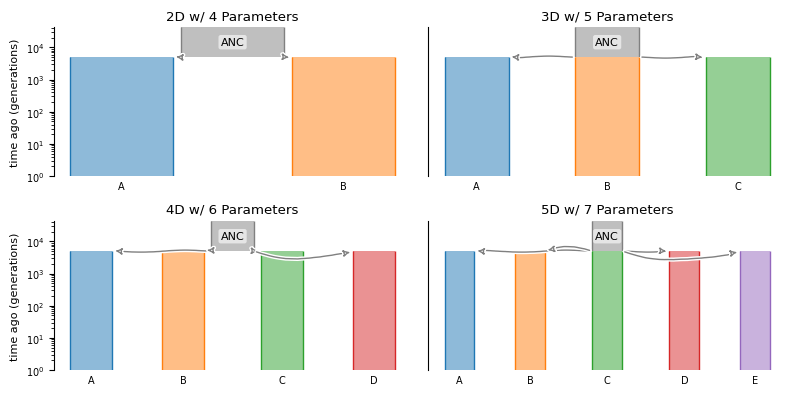

In [72]:
figure_name = "constant"

fig, axs = plt.subplots(2, 2, figsize=(8, 4), sharey=True)
axs = iter(axs.flatten())


colours = dict(
    zip(
        Pops,
        tuple(mcolors.TABLEAU_COLORS)[:5]
    )
)

demo_names =[
    '2D w/ 4 Parameters',
    '3D w/ 5 Parameters',
    '4D w/ 6 Parameters',
    '5D w/ 7 Parameters',
]

demo_names = iter(demo_names)
axis_off = False
for i in range(2, 6):
    exec(f'demo = get_demo_{i}()')
    pops = Pops[:i]
    ax = next(axs)
    demesdraw.tubes(demo, log_time=True, ax=ax, colours={i:colours[i] for i in pops})
    axis_off = ~axis_off
    ax.get_yaxis().set_visible(axis_off)
    demo_name = next(demo_names)
    ax.set_title(demo_name)
plt.tight_layout()
plt.savefig(f"{dissertation_dir}figures/chapter3/demo/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

## OOA MIG

In [73]:
Pops = ['YRI', 'CEU', 'CHB', 'ArchaicAFR', 'Neanderthal']

In [74]:
caption = "Parameters in Out-of-Africa Models"
tlabel = "tbl:ch3:OOAmigParams"

var_desc = {
    'Ancient size of YRI': (2,3,4,5,6),
    'Recent size of YRI': (2,3,4,5,6),
    'Size of Neanderthal': (5,6),
    'Size of ArchaicAFR': (4,5,6),
    'Ancient size of CEU': (2,3,4,5,6),
    'Size of CEU just before exp growth': (2,3,4,5,6),
    'Recent size of CEU': (2,3,4,5,6),
    'Size of CHB just before exp growth': (3,4,5,6),
    'Recent size of CHB': (3,4,5,6),
    'Migration rate between YRI and ArchaicAFR': (4,5),
    'Migration rate (1st) between YRI and CEU': (2,3,4,5),
    'Migration rate (2nd) between YRI and CEU': (2,3,4,5),
    'Migration rate between CEU and Neanderthal': (5,),
    'Migration rate between CHB and CEU': (3,4,5),
    'Migration rate between CHB and Neanderthal': (5,),
    'CHB-CEU split time \& Recent migration start time': (2,3,4,5,6),
    'Time of pulse migration from Neanderthal to CEU': (6,),
    'CEU-YRI split time': (2,3,4,5,6),
    'Time of pulse migration from YRI to Neanderthal' : (6,),
    'Start time of YRI-ArchaicAFR migration': (4,5),
    'Size change time of YRI': (2,3,4,5,6),
    'ArchaicAFR-YRI split time': (4,5,6),
    'Neanderthal-YRI split time': (5,6),
    'Pulse migration from Neanderthal to CEU': (6, ),
    'Pulse migration from YRI to Neanderthal': (6, )
}

cols = {}
total = {}
for i in range(2, 6):
    cols[f"OOA {i}D"] = ['\checkmark' if (i in j) else '' for j in var_desc.values() ]
cols[f"OOA 5DP"] = ['\checkmark' if (6 in j) else '' for j in var_desc.values() ]

total = [sum([i == '\\checkmark' for i in cols[demo]]) for demo in cols]

dx = pd.DataFrame(cols)
dx.index = tuple(var_desc)
dx = dx.style.to_latex()

dx = dx.split(split_line)
dx = (split_line + "\hline\n").join(dx[1:-1])
dx = dx + split_line + "\hline\hline\n\\bfseries Total number of parameters & " + " & ".join([str(i) for i in total])
head = "\\begin{tabular}{l|lllll}\n\multirow[c]{2}{*}{\\bfseries Parameters} & \\bfseries OOA 2D & \\bfseries OOA 3D & \\bfseries OOA 4D & \\bfseries OOA 5D & \\bfseries OOA 5D"
head = [head] + ['& ' + ' & '.join(4 * ['\\bfseries Migrations'] + ['\\bfseries Pulses']) + "\\\ \n\hline\hline\n"]
head = split_line.join(head)
dx = head + dx + split_line + '\hline\n\end{tabular}'

#dx = add_captions(dx, caption, tlabel)

text_file = open(f"{dissertation_dir}tables/OOAmig_params.tex", "w")
n = text_file.write(dx)
text_file.close()

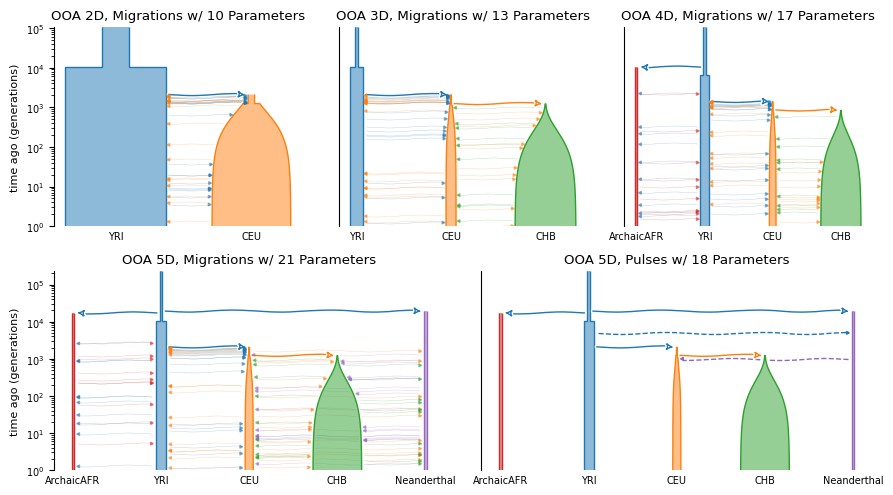

In [75]:
figure_name = "OOA"

fig = plt.figure(figsize = (9, 5))
gs = fig.add_gridspec(2,6)
axs = []
axs.append(fig.add_subplot(gs[0, :2]))
axs.append(fig.add_subplot(gs[0, 2:4]))
axs.append(fig.add_subplot(gs[0, 4:]))
axs.append(fig.add_subplot(gs[1, :3]))
axs.append(fig.add_subplot(gs[1, 3:]))
axs = iter(axs)

demo_names =[
    'OOA 2D, Migrations w/ 10 Parameters',
    'OOA 3D, Migrations w/ 13 Parameters',
    'OOA 4D, Migrations w/ 17 Parameters',
    'OOA 5D, Migrations w/ 21 Parameters'
]

desc_demos = {}

colours = dict(
    zip(
        Pops,
        tuple(mcolors.TABLEAU_COLORS)[:5]
    )
)

demo_names = iter(demo_names)
for i in range(2, 6):
    demo = demes.load(f'timing_tests_yaml/{i}_pop_mig.yaml')
    pops = demo.metadata['sampled_demes']
    ax = next(axs)
    
    if i in (2, 5):
        axis_show = True
    else:
        axis_show = False
    
    if i == 5:
        pos = ax.get_xticklabels()[:-1]        
        
    demesdraw.tubes(demo, log_time=True, ax=ax, colours={i:colours[i] for i in pops})
    ax.get_yaxis().set_visible(axis_show)
    demo_name = next(demo_names)
    ax.set_title(demo_name)

# 5 pop Pulses 
demo = demes.load(f'timing_tests_yaml/5_pop_2_admix.yaml')
pops = demo.metadata['sampled_demes']
ax = next(axs)
demesdraw.tubes(
    demo,
    log_time=True,
    ax=ax,
    colours={i:colours[i] for i in pops},
    positions={p.get_text(): p.get_position()[0] for p in pos}
)
ax.get_yaxis().set_visible(False)
plt.tight_layout()
ax.set_title('OOA 5D, Pulses w/ 18 Parameters')
plt.savefig(f"{dissertation_dir}figures/chapter3/demo/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)